# **Langchain의 create_agent 이해하기**

### 학습 내용
1. `create_agent` 함수의 기본 사용법 이해
2. `@tool` 데코레이터를 사용한 커스텀 도구 정의
3. 도구 파라미터 설정 방법
4. 에이전트 프롬프트 커스터마이징
5. 기본 에이전트 실행 및 테스트

## 1. 환경 설정

- Anthropic API Key 발급: https://console.anthropic.com/settings/keys

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

if os.environ.get("ANTHROPIC_API_KEY"):
    print("API Key가 설정되었습니다.")

API Key가 설정되었습니다.


## 2. 기본 에이전트 만들기

https://docs.langchain.com/oss/python/langchain/agents

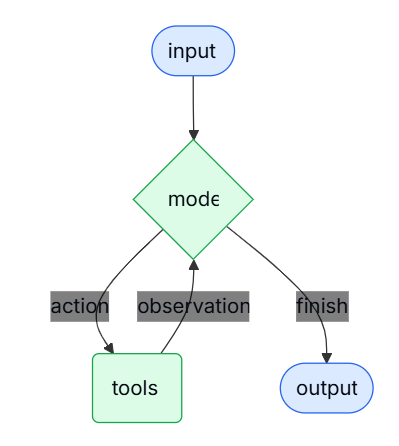

In [14]:
from langchain.agents import create_agent

def get_weather(city: str) -> str:
    """입력된 도시의 날씨를 반환하는 도구"""
    return f"{city}의 날씨는 항상 맑습니다!"

agent = create_agent(
    model="anthropic:claude-sonnet-4-6",
    tools=[get_weather],
    system_prompt="You are a helpful assistant",
)

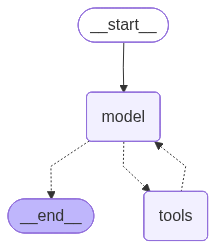

In [15]:
from IPython.display import Image, display

try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [16]:
response = agent.invoke(
    {"messages": [{"role": "user", "content": "서울의 날씨가 어떤가요?"}]}
)

print(response)

{'messages': [HumanMessage(content='서울의 날씨가 어떤가요?', additional_kwargs={}, response_metadata={}, id='1e9c2c9b-97e4-44b7-bd6e-7968269a0fb8'), AIMessage(content=[{'text': '서울의 날씨를 확인해 드리겠습니다!', 'type': 'text'}, {'id': 'toolu_019JcQppnd6Z9dZwvuVM7twW', 'caller': {'type': 'direct'}, 'input': {'city': '서울'}, 'name': 'get_weather', 'type': 'tool_use'}], additional_kwargs={}, response_metadata={'id': 'msg_01GMq9hRbpMj9M1PynwG6UT7', 'container': None, 'model': 'claude-sonnet-4-6', 'stop_details': None, 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'global', 'input_tokens': 594, 'output_tokens': 77, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-sonnet-4-6', 'model_provider': 'anthropic'}, id='lc_run--019e2022-41c2-7a50-bbe9-bcdb10dfb832-0', tool_calls=[{'name': 'get_weather', 'args': {'city

In [17]:
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

서울의 날씨가 어떤가요?
================================== Ai Message ==================================

[{'text': '서울의 날씨를 확인해 드리겠습니다!', 'type': 'text'}, {'id': 'toolu_019JcQppnd6Z9dZwvuVM7twW', 'caller': {'type': 'direct'}, 'input': {'city': '서울'}, 'name': 'get_weather', 'type': 'tool_use'}]
Tool Calls:
  get_weather (toolu_019JcQppnd6Z9dZwvuVM7twW)
 Call ID: toolu_019JcQppnd6Z9dZwvuVM7twW
  Args:
    city: 서울
================================= Tool Message =================================
Name: get_weather

서울의 날씨는 항상 맑습니다!
================================== Ai Message ==================================

서울의 현재 날씨는 **맑음** ☀️ 입니다! 오늘 하루도 좋은 날씨네요. 😊 외출하기 좋은 날씨인 것 같습니다!


## 3. @tool 데코레이터로 커스텀 도구 만들기

`@tool` 데코레이터를 사용하면 함수를 LangChain 도구로 쉽게 변환할 수 있습니다.

1. **함수 이름**: 도구의 이름이 되므로 명확하고 설명적으로 작성
2. **Docstring**: LLM이 도구의 용도를 이해하는 데 사용되므로 필수
3. **타입 힌트**: 파라미터와 반환값에 타입을 명시하여 LLM이 올바르게 호출하도록 도움

In [18]:
from langchain.tools import tool

@tool(parse_docstring=True)
def calculate_age(birth_year: int) -> str:
    """태어난 연도를 기준으로 나이를 계산합니다.

    Args:
        birth_year: 태어난 연도 (예: 1990)

    Returns:
        나이를 설명하는 텍스트(문자열)
    """
    from datetime import datetime
    current_year = datetime.now().year
    age = current_year - birth_year + 1
    return f"이 사람은 {age}세입니다. (현재 연도: {current_year})"

@tool(parse_docstring=True)
def multiply_numbers(a: float, b: float) -> str:
    """두 숫자를 곱합니다.

    Args:
        a: 첫 번째 숫자
        b: 두 번째 숫자

    Returns:
        a * b의 결과를 문자열로 반환
    """
    result = a * b
    return f"계산 결과: {a} × {b} = {result}"

print(f"\n도구 이름: {calculate_age.name}")
print(f"도구 설명: {calculate_age.description}")


도구 이름: calculate_age
도구 설명: 태어난 연도를 기준으로 나이를 계산합니다.


> 구글 스타일 독스트링: https://google.github.io/styleguide/pyguide.html#383-functions-and-methods

## 4. 다중 도구를 가진 에이전트 만들기

여러 개의 도구를 에이전트에 제공하면, LLM이 상황에 맞는 도구를 선택하여 사용합니다.

In [19]:
multi_tool_agent = create_agent(
    model="anthropic:claude-sonnet-4-6",
    tools=[calculate_age, multiply_numbers, get_weather],
    system_prompt="""You are a helpful assistant with access to multiple tools.
Use the appropriate tool based on the question.""",
)

In [20]:
response = multi_tool_agent.invoke(
    {"messages": [{"role": "user", "content": "난 1990년에 태어났어. 내 나이가 몇 살이야?"}]}
)

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

난 1990년에 태어났어. 내 나이가 몇 살이야?
================================== Ai Message ==================================

[{'text': '바로 계산해 드릴게요!', 'type': 'text'}, {'id': 'toolu_01K9KvVPGXqqL7n65qRa9J4U', 'caller': {'type': 'direct'}, 'input': {'birth_year': 1990}, 'name': 'calculate_age', 'type': 'tool_use'}]
Tool Calls:
  calculate_age (toolu_01K9KvVPGXqqL7n65qRa9J4U)
 Call ID: toolu_01K9KvVPGXqqL7n65qRa9J4U
  Args:
    birth_year: 1990
================================= Tool Message =================================
Name: calculate_age

이 사람은 37세입니다. (현재 연도: 2026)
================================== Ai Message ==================================

1990년생이시라면 현재 **37세**입니다! 🎉 (2026년 기준)


In [21]:
question = "15 곱하기 20은 얼마야? 그리고 서울의 날씨는 어때?"

for chunk in multi_tool_agent.stream({"messages": [{"role": "user", "content": question}]}, stream_mode="updates"):
    for node, value in chunk.items():
        print(f"노드: {node}")
        if "messages" in value:
            for message in value["messages"]:
                message.pretty_print()

노드: model
================================== Ai Message ==================================

[{'text': '두 질문에 대해 동시에 답변해드릴게요!', 'type': 'text'}, {'id': 'toolu_01W5yQyee4jQjpXvyPQcrmEb', 'caller': {'type': 'direct'}, 'input': {'a': 15, 'b': 20}, 'name': 'multiply_numbers', 'type': 'tool_use'}, {'id': 'toolu_01SMTQRXgryp1GBnhxWxVQnw', 'caller': {'type': 'direct'}, 'input': {'city': '서울'}, 'name': 'get_weather', 'type': 'tool_use'}]
Tool Calls:
  multiply_numbers (toolu_01W5yQyee4jQjpXvyPQcrmEb)
 Call ID: toolu_01W5yQyee4jQjpXvyPQcrmEb
  Args:
    a: 15
    b: 20
  get_weather (toolu_01SMTQRXgryp1GBnhxWxVQnw)
 Call ID: toolu_01SMTQRXgryp1GBnhxWxVQnw
  Args:
    city: 서울
노드: tools
================================= Tool Message =================================
Name: multiply_numbers

계산 결과: 15.0 × 20.0 = 300.0
노드: tools
================================= Tool Message =================================
Name: get_weather

서울의 날씨는 항상 맑습니다!
노드: model
================================== Ai Message 

## 5-1. 실전 연습: 사내 HR 챗봇

In [22]:
from typing import Optional

@tool(parse_docstring=True)
def check_annual_leave(employee_name: str) -> str:
    """직원의 남은 연차를 조회합니다.

    Args:
        employee_name: 직원 이름

    Returns:
        직원의 연차 정보
    """
    # 실제로는 HR 시스템 데이터베이스를 조회하겠지만, 여기서는 예시 데이터 사용
    annual_leave_data = {
        "김철수": {"total": 15, "used": 5, "remaining": 10},
        "이영희": {"total": 15, "used": 8, "remaining": 7},
        "박민수": {"total": 20, "used": 12, "remaining": 8},
        "최지원": {"total": 15, "used": 3, "remaining": 12},
    }

    if employee_name in annual_leave_data:
        data = annual_leave_data[employee_name]
        return f"""{employee_name}님의 연차 현황:
- 총 연차: {data['total']}일
- 사용한 연차: {data['used']}일
- 남은 연차: {data['remaining']}일"""
    else:
        return f"'{employee_name}' 직원의 정보를 찾을 수 없습니다. 이름을 다시 확인해주세요."

@tool(parse_docstring=True)
def get_company_contact(department: Optional[str] = None) -> str:
    """사내 부서별 연락처를 안내합니다.

    Args:
        department: 부서 이름 (예: 'HR', 'IT', '재무'). 지정하지 않으면 전체 연락처 반환

    Returns:
        부서 연락처 정보
    """
    contacts = {
        "HR": "📞 02-1234-5001 | 📧 hr@company.com | 위치: 본사 3층",
        "IT": "📞 02-1234-5002 | 📧 it@company.com | 위치: 본사 5층",
        "재무": "📞 02-1234-5003 | 📧 finance@company.com | 위치: 본사 4층",
        "마케팅": "📞 02-1234-5004 | 📧 marketing@company.com | 위치: 본사 6층",
        "영업": "📞 02-1234-5005 | 📧 sales@company.com | 위치: 본사 2층",
    }

    if department:
        if department in contacts:
            return f"{department} 부서 연락처:\n{contacts[department]}"
        else:
            available = ", ".join(contacts.keys())
            return f"'{department}' 부서를 찾을 수 없습니다. 사용 가능한 부서: {available}"
    else:
        result = "🏢 사내 연락처:\n\n"
        for dept, contact in contacts.items():
            result += f"[{dept}] {contact}\n"
        return result

@tool(parse_docstring=True)
def get_company_schedule(month: Optional[int] = None) -> str:
    """연간 회사 일정 및 행사를 안내합니다.

    Args:
        month: 조회할 월 (1-12). 지정하지 않으면 전체 일정 반환

    Returns:
        회사 일정 정보
    """
    schedule = {
        1: ["1/1 신정"],
        2: ["2/9-12 설날 연휴"],
        3: ["3/1 삼일절", "3/15 전사 워크샵"],
        4: ["4/5 식목일", "4/20 분기 전체 회의"],
        5: ["5/5 어린이날", "5/15 석가탄신일"],
        6: ["6/6 현충일", "6/30 상반기 결산"],
        7: ["7/20 여름 휴가 시즌 시작"],
        8: ["8/15 광복절"],
        9: ["9/16-18 추석 연휴"],
        10: ["10/3 개천절", "10/9 한글날", "10/25 하반기 전략회의"],
        11: ["11/15 송년 준비 회의"],
        12: ["12/25 성탄절", "12/27 송년회"],
    }

    if month:
        if 1 <= month <= 12:
            events = schedule.get(month, [])
            if events:
                return f"{month}월 일정:\n" + "\n".join(f"- {event}" for event in events)
            else:
                return f"{month}월에는 예정된 일정이 없습니다."
        else:
            return "월은 1부터 12 사이의 숫자여야 합니다."
    else:
        result = "📅 2026년 연간 주요 일정:\n\n"
        for m, events in schedule.items():
            result += f"[{m}월]\n"
            result += "\n".join(f"  - {event}" for event in events) + "\n\n"
        return result

@tool(parse_docstring=True)
def get_organization_chart(department: Optional[str] = None) -> str:
    """회사 조직도를 조회합니다.

    Args:
        department: 부서 이름. 지정하지 않으면 전체 조직도 반환

    Returns:
        조직도 정보
    """
    org_chart = {
        "경영진": ["CEO: 홍길동", "CFO: 김재무", "CTO: 이기술"],
        "HR": ["팀장: 김철수", "매니저: 이영희", "담당자: 박민수, 최지원"],
        "IT": ["팀장: 정개발", "시니어: 강코딩", "주니어: 윤프로"],
        "재무": ["팀장: 김재무", "매니저: 신회계", "담당자: 조예산"],
        "마케팅": ["팀장: 박마케", "매니저: 최광고", "담당자: 한브랜, 서소셜"],
        "영업": ["팀장: 강영업", "매니저: 류세일, 문고객"],
    }

    if department:
        if department in org_chart:
            members = org_chart[department]
            return f"{department} 부서 조직도:\n" + "\n".join(f"  - {member}" for member in members)
        else:
            available = ", ".join(org_chart.keys())
            return f"'{department}' 부서를 찾을 수 없습니다. 사용 가능한 부서: {available}"
    else:
        result = "🏢 회사 조직도:\n\n"
        for dept, members in org_chart.items():
            result += f"[{dept}]\n"
            result += "\n".join(f"  - {member}" for member in members) + "\n\n"
        return result

In [23]:
# 사내 HR 챗봇 에이전트 생성
hr_chatbot = create_agent(
    model="anthropic:claude-sonnet-4-6",
    tools=[
        check_annual_leave,
        get_company_contact,
        get_company_schedule,
        get_organization_chart
    ],
    system_prompt="""당신은 친절한 사내 HR 챗봇입니다.
    직원들의 다양한 질문에 답변하세요:
    - 연차 조회
    - 부서별 연락처 안내
    - 회사 일정 및 행사 안내
    - 조직도 조회

    항상 정확하고 친절하게 답변하며, 직원들이 필요한 정보를 쉽게 찾을 수 있도록 도와주세요.""",
)

In [24]:
# 연차 조회 테스트
response = hr_chatbot.invoke(
    {"messages": [{"role": "user", "content": "김철수 직원의 남은 연차가 얼마나 되나요?"}]}
)

print("\n=== 연차 조회 결과 ===")
print(response['messages'][-1].content)


=== 연차 조회 결과 ===
김철수 직원의 연차 현황을 안내해 드립니다! 📋

| 구분 | 일수 |
|------|------|
| 총 연차 | 15일 |
| 사용한 연차 | 5일 |
| **남은 연차** | **10일** |

김철수 직원의 **남은 연차는 현재 10일**입니다. 연차 사용과 관련하여 추가로 궁금한 점이 있으시면 언제든지 문의해 주세요! 😊


In [25]:
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

김철수 직원의 남은 연차가 얼마나 되나요?
================================== Ai Message ==================================

[{'text': '김철수 직원의 연차 정보를 조회해 드리겠습니다! 잠시만 기다려 주세요. 😊', 'type': 'text'}, {'id': 'toolu_018JMTy3hsQFkfiombqcmBDh', 'caller': {'type': 'direct'}, 'input': {'employee_name': '김철수'}, 'name': 'check_annual_leave', 'type': 'tool_use'}]
Tool Calls:
  check_annual_leave (toolu_018JMTy3hsQFkfiombqcmBDh)
 Call ID: toolu_018JMTy3hsQFkfiombqcmBDh
  Args:
    employee_name: 김철수
================================= Tool Message =================================
Name: check_annual_leave

김철수님의 연차 현황:
- 총 연차: 15일
- 사용한 연차: 5일
- 남은 연차: 10일
================================== Ai Message ==================================

김철수 직원의 연차 현황을 안내해 드립니다! 📋

| 구분 | 일수 |
|------|------|
| 총 연차 | 15일 |
| 사용한 연차 | 5일 |
| **남은 연차** | **10일** |

김철수 직원의 **남은 연차는 현재 10일**입니다. 연차 사용과 관련하여 추가로 궁금한 점이 있으시면 언제든지 문의해 주세요! 😊


In [26]:
# 사내 연락처 조회 테스트
response = hr_chatbot.invoke(
    {"messages": [{"role": "user", "content": "IT 부서 연락처 알려주세요"}]}
)

print("\n=== 연락처 조회 결과 ===")
print(response['messages'][-1].content)


=== 연락처 조회 결과 ===
IT 부서 연락처를 안내해 드립니다! 🖥️

| 항목 | 정보 |
|------|------|
| 📞 전화번호 | 02-1234-5002 |
| 📧 이메일 | it@company.com |
| 📍 위치 | 본사 5층 |

IT 관련 문의 사항이 있으시면 위 연락처로 문의해 주세요!
추가로 궁금하신 사항이 있으시면 언제든지 알려주세요. 😊


In [27]:
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

IT 부서 연락처 알려주세요
================================== Ai Message ==================================

[{'text': '네, IT 부서 연락처를 조회해 드리겠습니다! 잠시만 기다려 주세요. 😊', 'type': 'text'}, {'id': 'toolu_01NtvKQvuwc4oa6EL3yWtEPa', 'caller': {'type': 'direct'}, 'input': {'department': 'IT'}, 'name': 'get_company_contact', 'type': 'tool_use'}]
Tool Calls:
  get_company_contact (toolu_01NtvKQvuwc4oa6EL3yWtEPa)
 Call ID: toolu_01NtvKQvuwc4oa6EL3yWtEPa
  Args:
    department: IT
================================= Tool Message =================================
Name: get_company_contact

IT 부서 연락처:
📞 02-1234-5002 | 📧 it@company.com | 위치: 본사 5층
================================== Ai Message ==================================

IT 부서 연락처를 안내해 드립니다! 🖥️

| 항목 | 정보 |
|------|------|
| 📞 전화번호 | 02-1234-5002 |
| 📧 이메일 | it@company.com |
| 📍 위치 | 본사 5층 |

IT 관련 문의 사항이 있으시면 위 연락처로 문의해 주세요!
추가로 궁금하신 사항이 있으시면 언제든지 알려주세요. 😊


In [28]:
# 회사 일정 조회 테스트
response = hr_chatbot.invoke(
    {"messages": [{"role": "user", "content": "3월에 무슨 일정이 있나요?"}]}
)

print("\n=== 일정 조회 결과 ===")
print(response['messages'][-1].content)


=== 일정 조회 결과 ===
3월에는 다음과 같은 일정이 있습니다! 📅

| 날짜 | 일정 |
|------|------|
| 3월 1일 | 🇰🇷 **삼일절** (공휴일) |
| 3월 15일 | 🏕️ **전사 워크샵** |

- **삼일절(3/1)**은 공휴일로 휴무입니다.
- **전사 워크샵(3/15)**은 전 직원이 참여하는 행사이니 미리 일정을 확인해 두세요!

추가로 궁금한 사항이 있으시면 편하게 질문해 주세요 😊


In [29]:
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

3월에 무슨 일정이 있나요?
================================== Ai Message ==================================

[{'text': '3월 일정을 확인해 드릴게요! 잠시만 기다려 주세요 😊', 'type': 'text'}, {'id': 'toolu_01Rt1gb7DevfRPKqtXWCfQKm', 'caller': {'type': 'direct'}, 'input': {'month': 3}, 'name': 'get_company_schedule', 'type': 'tool_use'}]
Tool Calls:
  get_company_schedule (toolu_01Rt1gb7DevfRPKqtXWCfQKm)
 Call ID: toolu_01Rt1gb7DevfRPKqtXWCfQKm
  Args:
    month: 3
================================= Tool Message =================================
Name: get_company_schedule

3월 일정:
- 3/1 삼일절
- 3/15 전사 워크샵
================================== Ai Message ==================================

3월에는 다음과 같은 일정이 있습니다! 📅

| 날짜 | 일정 |
|------|------|
| 3월 1일 | 🇰🇷 **삼일절** (공휴일) |
| 3월 15일 | 🏕️ **전사 워크샵** |

- **삼일절(3/1)**은 공휴일로 휴무입니다.
- **전사 워크샵(3/15)**은 전 직원이 참여하는 행사이니 미리 일정을 확인해 두세요!

추가로 궁금한 사항이 있으시면 편하게 질문해 주세요 😊


## 5-2. 실전 연습: 온라인 쇼핑 상담 에이전트

사용자의 질문에 대해 다음 4가지 상담 대응이 가능한 에이전트를 만들어봅니다.

- 구매 가능한 제품 목록 조회하기
- 고객 상담 센터 전화번호 안내하기
- 주문 상태 조회하기
- 고객 정보(이름, 연락처, 주소지) 확인하기

In [32]:
from langchain.tools import tool
from langchain.agents import create_agent
from typing import Optional

@tool(parse_docstring=True)
def get_product_catalog(category: Optional[str] = None) -> str:
    """구매 가능한 제품 목록을 조회합니다.

    Args:
        category: 제품 카테고리 (예: 'electronics', 'clothing', 'books').
                  지정하지 않으면 전체 목록을 반환합니다.

    Returns:
        제품 목록 정보
    """
    products = {
        "electronics": [
            "노트북 - 1,200,000원",
            "무선 이어폰 - 150,000원",
            "스마트워치 - 350,000원"
        ],
        "clothing": [
            "티셔츠 - 25,000원",
            "청바지 - 89,000원",
            "운동화 - 120,000원"
        ],
        "books": [
            "파이썬 프로그래밍 - 32,000원",
            "AI 입문서 - 28,000원",
            "데이터 분석 가이드 - 35,000원"
        ]
    }

    if category:
        if category.lower() in products:
            items = products[category.lower()]
            return f"{category} 카테고리 제품:\n" + "\n".join(f"- {item}" for item in items)
        else:
            return f"'{category}' 카테고리를 찾을 수 없습니다. 사용 가능한 카테고리: electronics, clothing, books"
    else:
        all_products = []
        for cat, items in products.items():
            all_products.append(f"\n[{cat.upper()}]")
            all_products.extend(f"- {item}" for item in items)
        return "전체 제품 목록:" + "\n".join(all_products)

@tool(parse_docstring=True)
def get_customer_service_phone() -> str:
    """고객 상담 센터 전화번호를 안내합니다.

    Returns:
        고객 상담 센터 연락처 정보
    """
    return """고객 상담 센터 연락처:
📞 전화번호: 1588-1234
⏰ 운영시간: 평일 09:00 ~ 18:00 (주말 및 공휴일 휴무)
💬 상담 가능 언어: 한국어, 영어
📧 이메일: support@shopping.com"""

@tool(parse_docstring=True)
def check_order_status(order_id: str) -> str:
    """주문 상태를 조회합니다.

    Args:
        order_id: 주문 번호 (예: 'ORD-2024-001')

    Returns:
        주문 상태 정보
    """
    # 예시 주문 데이터
    orders = {
        "ORD-2024-001": {
            "product": "노트북",
            "status": "배송 중",
            "order_date": "2026-05-15",
            "expected_delivery": "2026-05-19"
        },
        "ORD-2024-002": {
            "product": "무선 이어폰",
            "status": "배송 완료",
            "order_date": "2026-04-20",
            "delivery_date": "2026-04-27"
        },
        "ORD-2024-003": {
            "product": "청바지",
            "status": "주문 확인 중",
            "order_date": "2026-05-17",
            "expected_delivery": "2026-05-21"
        }
    }

    order_id_upper = order_id.upper()
    if order_id_upper in orders:
        order = orders[order_id_upper]
        result = f"""주문 번호: {order_id_upper}
제품: {order['product']}
주문일: {order['order_date']}
상태: {order['status']}"""
        if 'delivery_date' in order:
            result += f"\n배송 완료일: {order['delivery_date']}"
        elif 'expected_delivery' in order:
            result += f"\n예상 배송일: {order['expected_delivery']}"
        return result
    else:
        return f"주문 번호 '{order_id}'를 찾을 수 없습니다. 주문 번호를 다시 확인해주세요."

@tool(parse_docstring=True)
def get_customer_info(customer_id: str) -> str:
    """고객 정보(이름, 연락처, 주소지)를 확인합니다.

    Args:
        customer_id: 고객 ID (예: 'CUST-001')

    Returns:
        고객 정보
    """
    # 예시 고객 데이터
    customers = {
        "CUST-001": {
            "name": "김철수",
            "phone": "010-1234-5678",
            "address": "서울특별시 강남구 테헤란로 123",
            "email": "kim@example.com"
        },
        "CUST-002": {
            "name": "이영희",
            "phone": "010-9876-5432",
            "address": "경기도 성남시 분당구 판교역로 456",
            "email": "lee@example.com"
        },
        "CUST-003": {
            "name": "박민수",
            "phone": "010-5555-7777",
            "address": "부산광역시 해운대구 해운대로 789",
            "email": "park@example.com"
        }
    }

    customer_id_upper = customer_id.upper()
    if customer_id_upper in customers:
        customer = customers[customer_id_upper]
        return f"""고객 ID: {customer_id_upper}
이름: {customer['name']}
연락처: {customer['phone']}
이메일: {customer['email']}
주소: {customer['address']}"""
    else:
        return f"고객 ID '{customer_id}'를 찾을 수 없습니다. 고객 ID를 다시 확인해주세요."

In [34]:
shopping_support_agent = create_agent(
    model="anthropic:claude-sonnet-4-6",
    tools=[
        get_product_catalog,
        get_customer_service_phone,
        check_order_status,
        get_customer_info
    ],
    system_prompt="""당신은 친절한 온라인 쇼핑 고객 지원 에이전트입니다.
    고객을 도와주세요:
    - 제품 카탈로그 문의
    - 고객 서비스 연락처 정보
    - 주문 상태 추적
    - 고객 정보 조회

    항상 정중하고 도움이 되며 정확한 정보를 제공하세요.
    고객이 도움을 받을 수 없는 질문을 하면,
    정중하게 고객 서비스에 문의하도록 안내하세요.""",
)

In [33]:
# 테스트
# 1. 전자제품 뭐가 있어요?
# 2. 고객센터 전화번호 알려주세요
# 3. 주문번호 ORD-2024-001 배송 언제 와요?
# 4. CUST-001 고객 정보 확인해주세요
# 5. 책 카테고리에는 어떤 제품이 있나요? 그리고 문제가 있으면 어디로 연락하면 되나요?
response = shopping_support_agent.invoke(
    {"messages": [{"role": "user", "content": "전자제품 뭐가 있어요?"}]}
)

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

전자제품 뭐가 있어요?
================================== Ai Message ==================================

[{'text': '전자제품 카탈로그를 조회해 드릴게요! 잠시만 기다려 주세요. 😊', 'type': 'text'}, {'id': 'toolu_01JTuf2wti1Ye73NMCSrRyHG', 'caller': {'type': 'direct'}, 'input': {'category': 'electronics'}, 'name': 'get_product_catalog', 'type': 'tool_use'}]
Tool Calls:
  get_product_catalog (toolu_01JTuf2wti1Ye73NMCSrRyHG)
 Call ID: toolu_01JTuf2wti1Ye73NMCSrRyHG
  Args:
    category: electronics
================================= Tool Message =================================
Name: get_product_catalog

electronics 카테고리 제품:
- 노트북 - 1,200,000원
- 무선 이어폰 - 150,000원
- 스마트워치 - 350,000원
================================== Ai Message ==================================

현재 판매 중인 전자제품 목록입니다! 📱💻

| 제품명 | 가격 |
|--------|------|
| 💻 노트북 | 1,200,000원 |
| 🎧 무선 이어폰 | 150,000원 |
| ⌚ 스마트워치 | 350,000원 |

관심 있으신 제품이 있으신가요? 추가로 궁금한 점이 있으시면 언제든지 말씀해 주세요! 😊


## 6. ToolRuntime을 활용한 컨텍스트 기반 도구

`ToolRuntime`을 사용하면 사용자가 매번 파라미터를 입력하지 않아도, 실행 컨텍스트에서 자동으로 정보를 가져와 사용할 수 있습니다.

### LangChain 1.0 권장 방식: `context` 파라미터 직접 전달

- **타입 안전성**: `dataclass`로 컨텍스트 스키마 정의
- **명확성**: `context` 파라미터로 직접 전달
- **편리성**: 사용자가 명시적으로 ID를 입력할 필요 없음

In [35]:
from dataclasses import dataclass
from langchain.tools import tool, ToolRuntime
from typing import Optional

# Context 타입 정의 (dataclass 권장)
@dataclass
class UserContext:
    """사용자 세션 컨텍스트"""
    customer_id: str

@tool(parse_docstring=True)
def get_my_orders(runtime: ToolRuntime[UserContext]) -> str:
    """현재 로그인한 사용자의 주문 내역을 조회합니다."""
    ctx = runtime.context

    # 주문 데이터베이스 (실제로는 DB 조회)
    user_orders = {
        "CUST-001": [
            {"order_id": "ORD-2024-101", "product": "노트북", "date": "2026-05-14", "status": "배송완료"},
            {"order_id": "ORD-2024-102", "product": "무선마우스", "date": "2026-05-17", "status": "배송중"},
        ],
        "CUST-002": [
            {"order_id": "ORD-2024-201", "product": "스마트워치", "date": "2026-05-12", "status": "배송완료"},
        ],
        "CUST-003": [
            {"order_id": "ORD-2024-301", "product": "무선이어폰", "date": "2026-05-17", "status": "주문확인중"},
            {"order_id": "ORD-2024-302", "product": "태블릿", "date": "2026-05-18", "status": "결제완료"},
        ]
    }

    customer_id = ctx.customer_id
    orders = user_orders.get(customer_id, [])

    if orders:
        result = f"📦 {customer_id} 회원님의 주문 내역:\n\n"
        for order in orders:
            result += f"• [{order['order_id']}] {order['product']}\n"
            result += f"  📅 주문일: {order['date']} | 상태: {order['status']}\n\n"
        return result
    else:
        return "주문 내역이 없습니다."

In [36]:
# context_schema를 지정하여 에이전트 생성
context_aware_agent = create_agent(
    model="anthropic:claude-sonnet-4-6",
    tools=[get_my_orders],
    context_schema=UserContext,
    system_prompt="""당신은 친절한 개인화 쇼핑 어시스턴트입니다. 항상 친절하고 개인화된 서비스를 제공하세요.""",
)

In [37]:
user1_context = UserContext(
    customer_id="CUST-001",
)

response = context_aware_agent.invoke(
    {"messages": [{"role": "user", "content": "주문 내역 조회해주세요."}]},
    context=user1_context
)

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

주문 내역 조회해주세요.
================================== Ai Message ==================================

[{'text': '네, 바로 주문 내역을 조회해 드리겠습니다! 잠시만 기다려 주세요. 😊', 'type': 'text'}, {'id': 'toolu_01BiSVP5tnEf8cd1ivE3UKoe', 'caller': {'type': 'direct'}, 'input': {}, 'name': 'get_my_orders', 'type': 'tool_use'}]
Tool Calls:
  get_my_orders (toolu_01BiSVP5tnEf8cd1ivE3UKoe)
 Call ID: toolu_01BiSVP5tnEf8cd1ivE3UKoe
  Args:
================================= Tool Message =================================
Name: get_my_orders

📦 CUST-001 회원님의 주문 내역:

• [ORD-2024-101] 노트북
  📅 주문일: 2026-05-14 | 상태: 배송완료

• [ORD-2024-102] 무선마우스
  📅 주문일: 2026-05-17 | 상태: 배송중


================================== Ai Message ==================================

CUST-001 회원님의 주문 내역을 확인했습니다! 📋

현재 총 **2건**의 주문 내역이 있습니다:

| 주문번호 | 상품명 | 주문일 | 상태 |
|---|---|---|---|
| ORD-2024-101 | 💻 노트북 | 2026-05-14 | ✅ 배송완료 |
| ORD-2024-102 | 🖱️ 무선마우스 | 2026-05-17 | 🚚 배송중

### 💡 ToolRuntime의 장점

1. **사용자 편의성**: 매번 customer_id를 입력할 필요 없음
2. **타입 안전성**: `dataclass`로 컨텍스트 스키마 명확히 정의
3. **보안성**: 세션/인증 정보를 컨텍스트로 관리
4. **유연성**: 다양한 메타데이터를 컨텍스트에 추가 가능
5. **개인화**: 각 사용자별로 다른 컨텍스트를 제공하여 맞춤형 서비스 구현

### 📌 실무 활용 예시

- **로그인 기반 챗봇**: 세션에서 사용자 ID 자동 추출
- **API 키 관리**: 외부 API 호출 시 필요한 인증 정보 전달

---
### 참고 자료

- [LangChain Agents 공식 문서](https://docs.langchain.com/oss/python/langchain/agents)
- [LangChain Tools 공식 문서](https://docs.langchain.com/oss/python/langchain/tools)
- [LangChain Quickstart](https://docs.langchain.com/oss/python/langchain/quickstart)
- [Langchain Runtime](https://docs.langchain.com/oss/python/langchain/runtime)